<a href="https://colab.research.google.com/github/vv2281/MAT-422/blob/main/HW1_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Homework 1.4

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#display numerial values with four decimal places
np.set_printoptions(precision=4, suppress=True)

##1.4.1 Singular Value Decomposition

Singular Value Decomposition (SVD) is a mathematical method that factors a matrix into three matrices.

For matrix A, the SVD is written as:

A = UΣVᵀ where:

-U contains the left singular vectors
-I contains the singular values
-V^T contains the right singular vectors
-The singular values are nonnegative and are arranged from largest to smallest.

A matrix can also be represented as: A = Σ σᵢuᵢvᵢᵀ

This means that a matrix can be expressed as a sum of rank-one matrices. SVD is useful in data analysis, image compression, dimensionality reduction, and solving numerial problems.

In [2]:
#example matrix

A = np.array([
    [3,2,2],
    [2,3,-2]
], dtype=float)

print("Original matrix A:")
print(A)

print("\nShape of A:")
print(A.shape)

Original matrix A:
[[ 3.  2.  2.]
 [ 2.  3. -2.]]

Shape of A:
(2, 3)


In [3]:
#calculating the singular value decomposition
U, singular_values, VT = np.linalg.svd(
    A,
    full_matrices=False
)

#convert the singular values into a diagnoal matrix
Sigma = np.diag(singular_values)

print("Matrix U:")
print(U)

print("\nSingular values:")
print(singular_values)

print("\nMatrix Sigma:")
print(Sigma)

print("\nMatrix Sigma:")
print(Sigma)

print("\nMatrix V^T:")
print(VT)

Matrix U:
[[-0.7071 -0.7071]
 [-0.7071  0.7071]]

Singular values:
[5. 3.]

Matrix Sigma:
[[5. 0.]
 [0. 3.]]

Matrix Sigma:
[[5. 0.]
 [0. 3.]]

Matrix V^T:
[[-0.7071 -0.7071 -0.    ]
 [-0.2357  0.2357 -0.9428]]


##Reconstructing the Original Matrix
The original matrix can be reconstructed by multiplying the three SVD matrices: A = UΣVᵀ

If the decomposition is correct, the reconstructed matrix should be equal to the original matrix, except for very small numerial rounding errors.


The Frobenius norm can be used to measure the reconstruction error: ||A - Â||F

A reconstruction error close to zero means that the matrix was reconstructed accurately.

In [4]:
#reconstructing the original matrix

A_reconstructed = U @ Sigma @ VT

#calculating the reconstruction error
reconstruction_error = np.linalg.norm(
    A - A_reconstructed,
    ord="fro"
)

print("Reconstructed matrix:")
print(A_reconstructed)

print("\nFrobenius reconstruction error:")
print(reconstruction_error)

Reconstructed matrix:
[[ 3.  2.  2.]
 [ 2.  3. -2.]]

Frobenius reconstruction error:
1.5543122344752192e-15


##Checking the Orthonormality of U and V

The columns of U are orthonormal. (AKA: UᵀU = I)

The rows of V^T are also orthonormal. Vᵀ(Vᵀ)ᵀ = I

In [ ]:
print("U^T @ U:")
print(U.T @ U)

print("\nVT @ VT^T:")
print(VT @ VT.T)

print("\nExpected identity matrix:")
print(np.eye(U.shape[1]))

##1.4.2 Low Rank Matrix Approximations

A low rank matrix approximation uses only some of the singular values from the SVD. The rank-k approximation is:

Aₖ = UₖΣₖVₖᵀ

where:

- Uₖ contains the first k left singular vectors.
- Σₖ contains the first k singular values.
- Vₖᵀ contains the first k right singular vectors.

Because the singular values are arranged from largest to smallest, the first singular values generally contain the most important information.

For example,
-A(1) is a rank one approximation.
-A(2) is a rank two approximation.

In [9]:
def low_rank_approximation(matrix, rank):
  """
  Construct a rank-k approximation using SVD.
  """
  U, s, VT = np.linalg.svd(
      matrix,
      full_matrices=False
  )
  #make sure the requested rank is valid
  rank = min(rank, len(s))

  #reconstruct the matrix using only the first k singular values
  approximation = (
      U[:, :rank]
      @ np.diag(s[:rank])
      @ VT[:rank, :]
  )
  return approximation
  #create rank one and rank two approximations

A_rank_1 = low_rank_approximation(A,1)
A_rank_2 = low_rank_approximation(A,2)

print("Original matrix:")
print(A)

print("\nRank-1 approximation:")
print(A_rank_1)

print("\nRank-2 approximation:")
print(A_rank_2)

Original matrix:
[[ 3.  2.  2.]
 [ 2.  3. -2.]]

Rank-1 approximation:
[[2.5 2.5 0. ]
 [2.5 2.5 0. ]]

Rank-2 approximation:
[[ 3.  2.  2.]
 [ 2.  3. -2.]]


##Comparing Approximation Errors

The approximation error is calculated using the Frobenius norm: ||A - Aₖ||F

As the rank increases, the approximation should become more accurate. When all singular values are included, the approximation reproduces the original matrix.

In [11]:
#Calculating the error for each possible rank

ranks = list(range(1, len(singular_values) +1))
errors = []

for rank in ranks:
  approximation = low_rank_approximation(A,rank)

  error = np.linalg.norm(
      A - approximation,
      ord="fro"
  )

  errors.append(error)

  #store the results in a table
  error_table = pd.DataFrame({
      "Rank k": ranks,
      "Frobenius Error": errors
  })
print(error_table)

##Visualizing the Original Matrix and Its Approximation

The following heatmaps compare the original matrix with its rank one and rank two approximation. The rank one approximation uses only the largest singular value. The rank two approximation uses two singular values and should be more accurate.

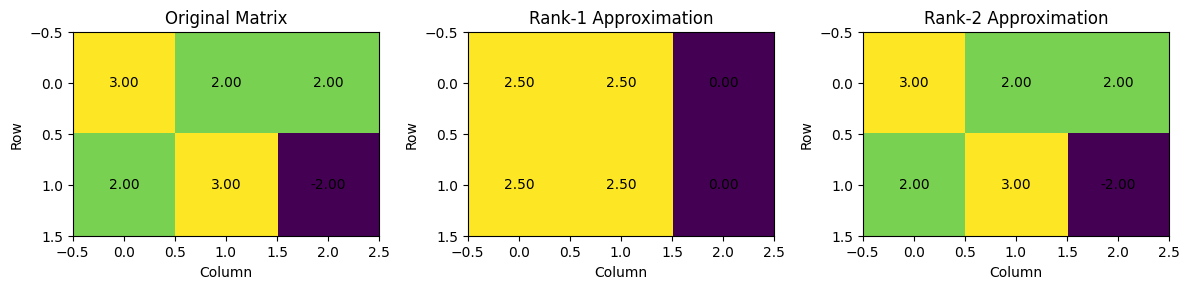

In [13]:
#Displaying the original matrix and its approximations

plt.close("all")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

matrices = [A, A_rank_1, A_rank_2]

titles = [
    "Original Matrix",
    "Rank-1 Approximation",
    "Rank-2 Approximation"
]

for i in range(3):

    axes[i].imshow(matrices[i], cmap="viridis")

    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Column")
    axes[i].set_ylabel("Row")

    # Display the values inside each heatmap
    for row in range(matrices[i].shape[0]):
        for col in range(matrices[i].shape[1]):

            axes[i].text(
                col,
                row,
                f"{matrices[i][row, col]:.2f}",
                ha="center",
                va="center"
            )

plt.tight_layout()
plt.show()

##Interpretation of the Low Rank Approximations

The rank one approximation captures the strongest overall pattern in the matrix. The rank two approximation is more accurate because it includes an additional singular value and its corresponding singular vectors. As more singular values are included, the approximation error decreases. Low rank approximations are useful for compressing data, reducing computational work, and simplifying large matrices.

#1.4.3 Principal Component Analysis

Principal Component Analysis (PCA) is a technique used to reduce the number of variables in a dataset while preserving as much variation as possible.

PCA follows these main steps:

1.Center the data by subtracting the mean of each feature.
2. Compute the SVD of the centered data matrix.
3. Identify the principal directions.
4. Project the data onto those directions.

If the centered data matrix is Xc, then: Xc = UΣVᵀ

The principal directions are the columns of V. The transformed data are calculated using: Z = XcV

The explained variance ratio for each component is:

Explained Variance Ratio = σᵢ² / Σ σⱼ²

The first principal component captures the greatest amount of variation in the data. PCA is commonly used for visualization, dimensionality reduction, data compression, and identifying patterns in datasets.

In [15]:
#Set a random number generator for reproducibility

rng = np.random.default_rng(42)

#create a dataset with two related features

x = np.linspace(-5,5,100)

y = (
    2.5 * x
    + rng.normal(0,1.2,size=100)
)
#combine the features into a matrix

X = np.column_stack((x,y))
print("First five observations:")
print(X[:5])

print("\nDataset shape:")
print(X.shape)

First five observations:
[[ -5.     -12.1343]
 [ -4.899  -13.4955]
 [ -4.798  -11.0944]
 [ -4.697  -10.6137]
 [ -4.596  -13.8311]]

Dataset shape:
(100, 2)


##Centering the Data

PCA requires the data to be centered. Centering means subtracting the mean of each feature from every observation. After centering, each feature should have a mean close to zero.

In [17]:
#Calculating the mean of each feature
feature_means = X.mean(axis=0)

#Center the data
X_centered = X - feature_means

print("Feature means:")
print(feature_means)

print("\nMeans after centering:")
print(X_centered.mean(axis=0))

Feature means:
[ 0.     -0.0603]

Means after centering:
[ 0. -0.]


##Applying SVD to the Centered Data

We can calculate the SVD of the centered matrix.

The columns of V are the principal directions.

The transformed data are found by multiplying the centered data by the principal directions: Z = XcV

The explained variance ratio tells us how much of the total variation is represented by each principal component.

In [18]:
# Compute the SVD of the centered data
U_pca, s_pca, VT_pca = np.linalg.svd(
    X_centered,
    full_matrices=False
)

#The columns of V are the principal directions
principal_directions = VT_pca.T

#Project the data onto the principal directions
principal_components = (
    X_centered @ principal_directions
)

#Calculating the explained variance
explained_variance = (
    s_pca**2 / (len(X_centered) - 1)
)

#Calculating the explained variance ratio
explained_variance_ratio = (
    explained_variance
    / explained_variance.sum()
)

#Creating a PCA results table
pca_table = pd.DataFrame({
    "Principal Component": ["PC1", "PC2"],
    "Singular Value": s_pca,
    "Explained Variance": explained_variance,
    "Explained Variance Ratio": explained_variance_ratio,
    "Cumulative Variance Ratio": np.cumsum(
        explained_variance_ratio
    )
})

print("Principal directions:")
print(principal_directions)

print("\nPCA results:")
print(pca_table)

Principal directions:
[[ 0.3734 -0.9277]
 [ 0.9277  0.3734]]

PCA results:
  Principal Component  Singular Value  Explained Variance  \
0                 PC1       77.613672           60.847293   
1                 PC2        3.439882            0.119523   

   Explained Variance Ratio  Cumulative Variance Ratio  
0                   0.99804                    0.99804  
1                   0.00196                    1.00000  


##Visualizing the Principal Directions

The first principal component points in the direction of greatest variation in the data. The second principal component is perpendicular to the first and represents the remaining variation.

In [ ]:
plt.figure(figsize=(8, 6))

#Plot the centered data
plt.scatter(
    X_centered[:, 0],
    X_centered[:, 1],
    alpha=0.7,
    label="Centered Data"
)

#Draw the principal directions
for i in range(2):

    direction = principal_directions[:, i]

    plt.arrow(
        0,
        0,
        5 * direction[0],
        5 * direction[1],
        width=0.03,
        length_includes_head=True,
        label=f"PC{i + 1}"
    )

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("Centered Feature 1")
plt.ylabel("Centered Feature 2")
plt.title("Centered Data and Principal Directions")
plt.legend()
plt.grid(True)
plt.show()

##Reducing the Data to One Principal Component

Because the data has a strong linear relationship, most of the variation can be represented by the first principal component. We keep only the first principal component. Which is: Z₁ = Xcv₁

The approximate reconstruction is: X̂ = Z₁v₁ᵀ + feature means

This allows us to represent two dimensional data using only one dimension.

In [19]:
#Keeping only the first principal component
Z_one_component = principal_components[:, :1]

#Reconstructing the centered data using only PC1
X_centered_reconstructed = (
    Z_one_component
    @ principal_directions[:, :1].T
)

#Adding the feature means back
X_reconstructed = (
    X_centered_reconstructed
    + feature_means
)

#Calculating the PCA reconstruction error
pca_reconstruction_error = np.linalg.norm(
    X - X_reconstructed,
    ord="fro"
)

print("Shape of the one-component representation:")
print(Z_one_component.shape)

print("\nFirst five component scores:")
print(Z_one_component[:5])

print("\nPCA reconstruction error:")
print(pca_reconstruction_error)

Shape of the one-component representation:
(100, 1)

First five component scores:
[[-13.0677]
 [-14.2926]
 [-12.0276]
 [-11.544 ]
 [-14.4909]]

PCA reconstruction error:
3.4398815577485227


##Comparing the Original Data with the Reconstruction

The following graph compares the original two dimensional dataset with the reconstruction created using only one principal component.

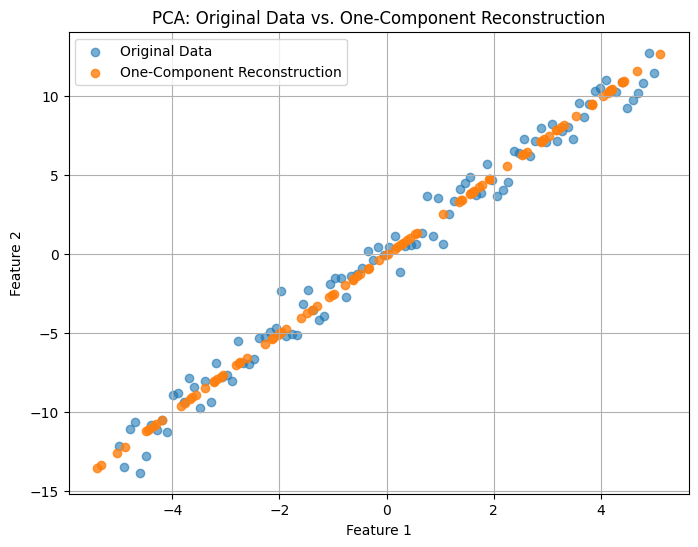

In [20]:
plt.figure(figsize=(8, 6))

#Original data
plt.scatter(
    X[:, 0],
    X[:, 1],
    alpha=0.6,
    label="Original Data"
)

#Reconstructed data
plt.scatter(
    X_reconstructed[:, 0],
    X_reconstructed[:, 1],
    alpha=0.8,
    label="One-Component Reconstruction"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title(
    "PCA: Original Data vs. One-Component Reconstruction"
)

plt.legend()
plt.grid(True)
plt.show()

##Interpretation of the PCA Results

The explained variance ratio shows how much of the total variation is captured by each principal component:

- PC1 captures the greatest amount of variation.
- PC2 captures the remaining variation.
- If PC1 explains most of the variance, the dataset can be represented effectively using one dimension.
